# Predicting Billboard #1 Hits

**Authors:** May Eindra Tet Toe, Anastasia Tountas, Tran Anh Thu Phung, Harry Nguyen  
**Date:** 2026-03-21

# Summary

The objective of this analysis is to use publicly available song information from the Billboard Hot 100 song rankings to investigate the question:

**Given various metrics about a song (energy, beats per minute, etc.), how many weeks, if any, will a song remain at the top position in the Billboard Hot 100 rankings? Which features contribute most to our model's predictions?**

# Introduction

The magazine "Billboard" is a leading source of information on trends in music popularity and innovation. Following the launch of the magazine in 1958, weekly rankings of the top 100 songs in the US have been made publicly available [@billboard]. The dataset that we have selected is open-source Tidy Tuesday [@tidytuesday] dataset which documents these billboard rankings from August 4th 1958, until January 11th 2025. It provides features such as lyrics, song-structure, and featured_artists for each song in the ranking. These features can then be used for song popularity predictions or music trend forecasting. In this analysis, we use linear regression to predict the number of weeks a song remains at the #1 spot in the rankings, and assess our model's performance using RMSE, MAE and $R^2$. Even though our results show that our regressor has a weak performance, information regarding feature importances in model decision-making remain useful in determining a song's overall popularity.

# Methods and Results

## Overview of our Methodology

The Billboard Hot 100 dataset provides us with two datasets: `billboard.csv`, which contains one row per song that reached #1 along with its features, and `topics.csv`, a reference list of lyrical theme labels (`lyrical_topics`). Our team decided to combine the two datasets to create more comprehensive data to better equip our model. Here is an overview of our data analysis methodology:

1. **Reading & Wrangling:** Read and wrangle the dataset into one tidy combined dataset.
2. **Exploratory Data Analysis:** Explore the data to understand the distribution of features and their relationships with the target variable.
3. **Feature Transformations & Selection:** Split the cleaned data first, then learn log transformations, one-hot encoding, and near-zero variance filtering from the training split only before applying the same transformations to the test split. This avoids leaking test-set information into feature selection.
4. **Model Building & Evaluation:** Split the data 70/30, fit an ordinary least squares model using a `tidymodels` workflow. Evaluate the model using repeated 5-fold cross-validation and test set metrics (RMSE, $R^2$, MAE).
5. **Results and Conclusion:** Summarize findings, discuss implications, and suggest potential future work.

## Load libraries and set seed

In [ ]:
library(tidyverse)
library(tidymodels)
library(caret)
library(broom)
library(knitr)
library(dsci310billboardanalysis)

set.seed(123)

## Reading & Wrangling our dataset from the web into R

-   The two datasets were joined using a `left_join()` on `lyrical_topic` (billboard) and `lyrical_topics`(topics).
-   **Identifier columns** (`song`, `artist`, `date`) were removed as they are not predictive features.
-   **`non_consecutive`** was removed to prevent data leakage — it can only be determined after a song has completed its full chart run.
-   **`rating_1`, `rating_2`, `rating_3`** were removed in favour of `overall_rating` (their mean) to avoid multicollinearity.
-   **Free-text columns** were removed avoid the high dimensionality and noise associated with Natural Language Processing: `lyrics`, `u_s_artwork`, `sound_effects`, `song_structure`, `featured_artists`, `songwriters`, `songwriters_w_o_interpolation_sample_credits`, `producers`, `double_a_side`, and `talent_contestant`.
-   **High-cardinality columns** removed because they generalise poorly: `label`, `parent_label`, and `artist_place_of_origin`.
-   **Redundant columns** were removed: `keys` is replaced by `simplified_key`; `cdr_style` and `discogs_style` are replaced by `cdr_genre` and `discogs_genre` respectively.
-   **`discogs_genre`** was removed in favour of `cdr_genre` because cdr has more reliable class definitions, thus improving internal validity.
-   **Ambiguous columns** were removed: `featured_in_a_then_contemporary_play`, `featured_in_a_then_contemporary_film`, and `featured_in_a_then_contemporary_t_v_show`.
-   All remaining character columns were converted to factors using `as.factor()`, and rows with any missing values were dropped with `drop_na()`.

In [ ]:
# Extract the datasets
billboard <- read_csv(
  "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-08-26/billboard.csv"
)
topics <- read_csv(
  "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-08-26/topics.csv"
)

In [66]:
# Join the two datasets
billboard_joined <- billboard |>
  left_join(topics, by = c("lyrical_topic" = "lyrical_topics"))

In [67]:
# Save raw datasets to data/raw/
dir.create("../data/raw", recursive = TRUE, showWarnings = FALSE)
write_csv(billboard, "../data/raw/billboard.csv")
write_csv(topics, "../data/raw/topics.csv")

billboard_clean <- billboard_joined |>
  # Remove identifier columns
  select(-c(song, artist, date)) |>
  # Remove data-leakage column
  select(-non_consecutive) |>
  # Remove individual judge scores to avoid multicollinearity
  select(-c(rating_1, rating_2, rating_3)) |>
  # Remove free-text columns
  select(-c(
    lyrics,
    u_s_artwork,
    sound_effects,
    song_structure,
    featured_artists,
    songwriters,
    songwriters_w_o_interpolation_sample_credits,
    producers,
    double_a_side,
    talent_contestant
  )) |>
  # Remove high-cardinality columns
  select(-c(label, parent_label, artist_place_of_origin)) |>
  # Remove redundant columns and discogs_genre
  select(-c(cdr_style, discogs_style, keys, discogs_genre)) |>
  # Remove ambiguous columns
  select(-c(
    featured_in_a_then_contemporary_play,
    featured_in_a_then_contemporary_film,
    featured_in_a_then_contemporary_t_v_show
  )) |>
  # Convert remaining character columns to factors
  mutate(across(where(is.character), as.factor)) |>
  drop_na()

## Exploratory Data Analysis

First, we find the summary statistics for our target variable, `weeks_at_number_one`, and our key numeric predictors: `overall_rating`, `bpm`, `energy`, `danceability`, `happiness`, `acousticness`, `loudness_d_b`, `front_person_age`, and `length_sec`.

In [ ]:
compute_summary_stats(
  billboard_clean,
  c("weeks_at_number_one", "overall_rating", "bpm",
    "energy", "danceability", "happiness",
    "acousticness", "loudness_d_b", "front_person_age", "length_sec")
) |>
  kable(caption = "Table 1: Summary statistics for target and key predictors.")

Then, we examine the distribution of our target variable, `weeks_at_number_one`, to check for skewness.

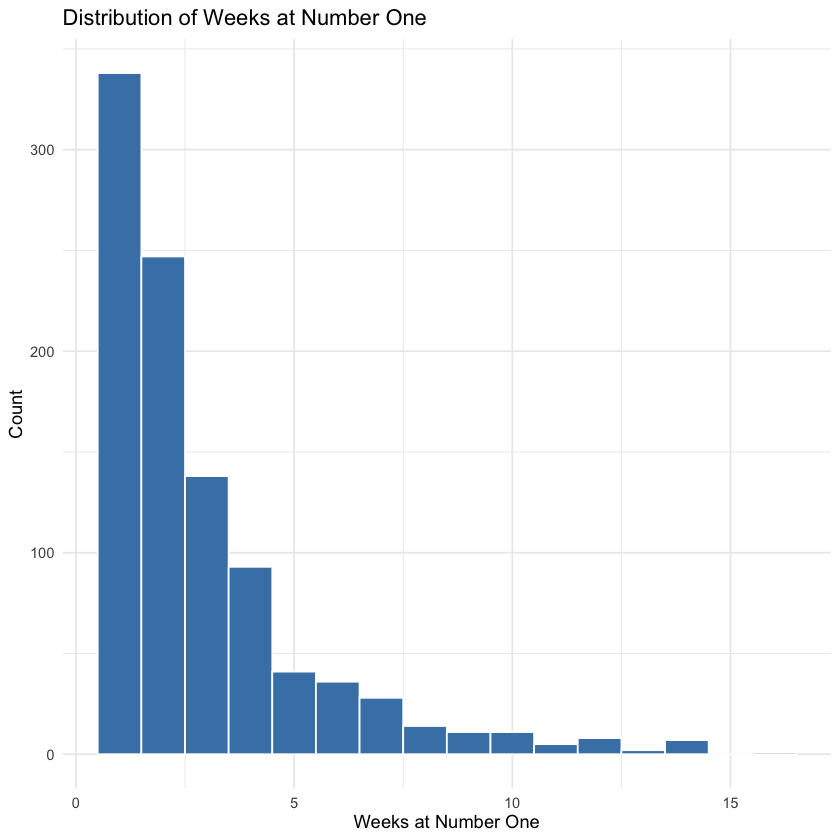

In [69]:
ggplot(billboard_clean, aes(x = weeks_at_number_one)) +
  geom_histogram(binwidth = 1, fill = "steelblue", colour = "white") +
  labs(
    title = "Distribution of Weeks at Number One",
    x = "Weeks at Number One",
    y = "Count"
  ) +
  theme_minimal()

*Figure 1. Distribution of weeks at number one.*

The distribution is heavily right-skewed. The majority of songs spent only 1 to 3 weeks at #1, with counts dropping off sharply afterwards. A small number of songs stayed for 10 or more weeks, forming a long right tail.

Next, we examine the distributions of the five Spotify audio features, to identify any skewness that may require transformation before modelling.

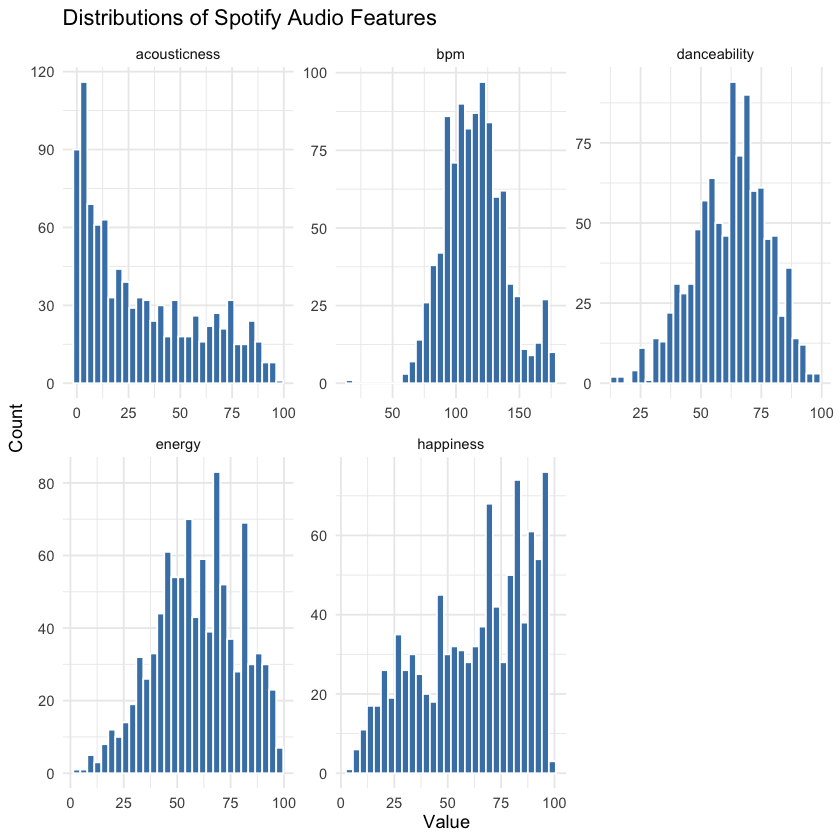

In [70]:
billboard_clean |>
  select(bpm, energy, danceability, happiness, acousticness) |>
  pivot_longer(cols = everything(), names_to = "feature", values_to = "value") |>
  ggplot(aes(x = value)) +
  geom_histogram(fill = "steelblue", colour = "white", bins = 30) +
  facet_wrap(~feature, scales = "free") +
  labs(
    title = "Distributions of Spotify Audio Features",
    x = "Value",
    y = "Count"
  ) +
  theme_minimal()

*Figure 2. Distributions of the five Spotify audio features.*

`acousticness` is heavily right-skewed, with most songs clustered near zero. `happiness` shows a bimodal pattern with peaks around 30 and around 80. `energy` is very slightly left-skewed, while `bpm` and `danceability` are roughly normal.

Finally, we compare average `weeks_at_number_one` by genre to see whether certain genres are associated with longer chart runs.

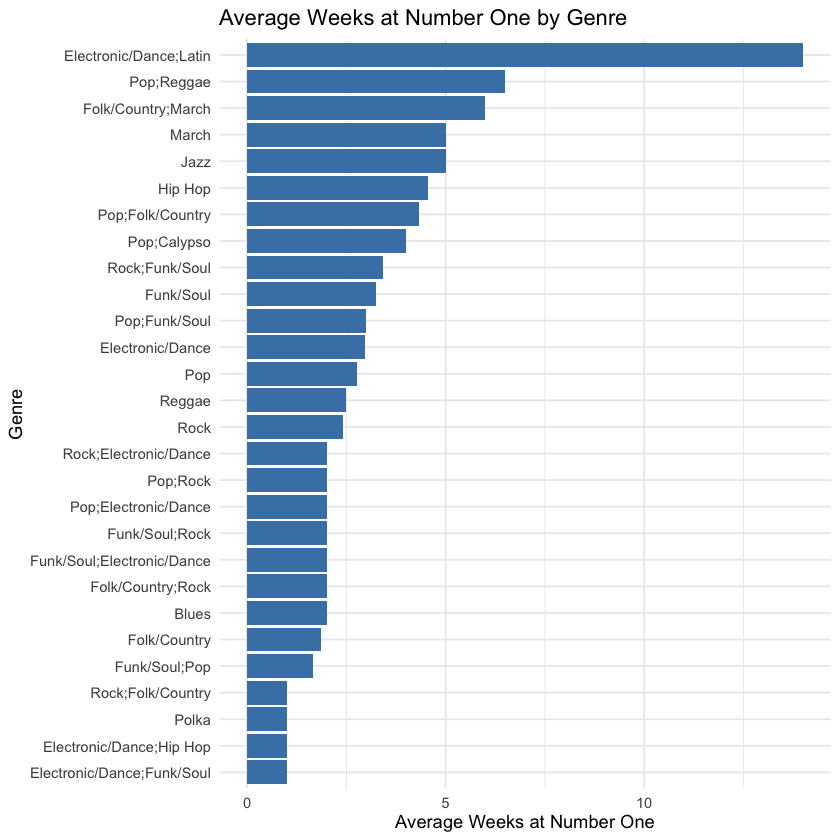

In [71]:
billboard_clean |>
  group_by(cdr_genre) |>
  summarise(mean_weeks = mean(weeks_at_number_one), .groups = "drop") |>
  ggplot(aes(x = reorder(cdr_genre, mean_weeks), y = mean_weeks)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Average Weeks at Number One by Genre",
    x = "Genre",
    y = "Average Weeks at Number One"
  ) +
  theme_minimal()

*Figure 3. Average weeks at number one by genre.*

Electronic/Dance;Latin seems to have the highest average (\~10 weeks). Pop;Reggae and Folk/Country;March also rank highly. Mainstream genres like Pop and Rock sit in the middle of the range. At the lower end, we can find niche genres like Electronic/Dance;Funk/Soul, averaging to 1 week.


## Feature Transformations

Based on the Exploratory Data Analysis, two variables require transformation before modelling:

-   **`weeks_at_number_one`** is heavily right-skewed
-   **`acousticness`** is also heavily right-skewed

Therefore, we apply log transformation to these three variables to compresses the tail and produce a more symmetric target distribution. We will be using `log1p()` instead of `log()` to handle any zero values in the data.


In [72]:
billboard_log_transformed <- billboard_clean |> 
  mutate(
    log_weeks_at_number_one = log1p(weeks_at_number_one),
    log_acousticness = log1p(acousticness)
  )

Moreover, several songs in the dataset were associated with more than one musical genre (for example, `Electronic/Dance; Latin` or `Pop;Funk/Soul`). Treating these combined labels as single categorical values would incorrectly imply that each combination represents a distinct genre and would lead to sparse, poorly interpretable factor levels. To address this, the `cdr_gerne` variable was processed as a multi-label feature. Individual genre were first separated into their component parts and then encoded as binary indicator variables using one-hot encoding.

In [73]:
billboard_genres <- billboard_log_transformed |> 
  separate_rows(cdr_genre, sep = ";") |> 
  mutate (cdr_genre = str_trim(cdr_genre))

billboard_genres_wide <- billboard_genres |> 
  mutate(value = 1) |> 
  pivot_wider(
    names_from = cdr_genre, 
    values_from = value,
    values_fill = 0
  )

The `simplified_key` variable originally contained 25 levels representing individual musical keys in standard notation (e.g. `C`, `Am`, `Bbm`). Retaining all 25 levels would generate an excessive number of dummy variable during modelling, introducing sparsity and increasing the risk of overfitting. To address this, the keys were collapsed into three musically meaningful categories: Major (e.g. `C`, `Ab`, `F`), Minor (e.g. `Am`,`Bbm`, `Em`), and Multiple Keys.


In [74]:
billboard_simplify_key <- billboard_genres_wide |> 
  mutate(
    simplified_key = case_when(
      simplified_key == "Multiple Keys"          ~ "Multiple Keys",
      str_ends(simplified_key, "m")              ~ "Minor",  
      TRUE                                        ~ "Major"  
    ) |> as.factor()
  )

billboard_model_final <- billboard_simplify_key |> 
  select(-weeks_at_number_one, -acousticness)

### Feature Selection

#### Drop Redundant Columns

Columns were dropped on conceptual grounds across five categories:

-   Demographic identity columns encoding the race and gender of artists, songwriters, and producers.
-   Artist structure indicators, songwriter/producer role overlap columns.
-   Timing-derived columns.
-   Lyric redundant content.
-   External content.

In [75]:
columns_to_drop <- c(
  # Demographic identity
  "artist_male","artist_white", "artist_black", "songwriter_male", "songwriter_white", "producer_male", "producer_white", 
  # Artist structure
  "artist_structure", "group_named_after_non_lead_singer",
  # Songwriter/producer overlaps
  "artist_is_only_songwriter", "artist_is_only_producer", "songwriter_is_a_producer",
  # Timing
  "instrumental_length_sec",  "intro_length_sec",
  # Lyrical content 
  "lyrical_topic","lyrical_narrative",
  # External content
  "written_for_a_play", "written_for_a_film", "written_for_a_t_v_show", "eurovision_entry", "topped_the_charts_by_multiple_artist", "associated_with_dance")

billboard_manual_dropped <- billboard_model_final |>
  select(-all_of(columns_to_drop))

#### Drop columns with nearly zero variance

Near-zero variance predictors were identified and removed using `nearZeroVar()` from the `caret` package. A predictor was flagged for removal if it met either of two criteria: its most common value appeared at least 19 times more frequently than the second most common value (`freqCut = 95/5`), or fewer than 5% of its values were unique (`uniqueCut = 5`).


In [76]:
# Identify and remove near-zero variance predictors
nzv_cols <- nearZeroVar(billboard_manual_dropped, 
                        freqCut = 95/5,  
                        uniqueCut = 5,
                        names = TRUE)

billboard_model_selected <- billboard_manual_dropped |>
  select(-all_of(nzv_cols))

# Save processed dataset
dir.create("../data/processed", recursive = TRUE, showWarnings = FALSE)
write_csv(billboard_model_selected, "../data/processed/billboard_model_selected.csv")

### Regression Model

Split the dataset into training and testing sets, with 705 of the observations allocated to the training set and 30% to the testing set.


In [77]:
# Train/test split
billboard_split <- initial_split(billboard_model_selected, prop = 0.7)
train_data <- training(billboard_split)
write_csv(train_data, "../data/processed/billboard_model_training.csv")
test_data <- testing(billboard_split)
write_csv(test_data, "../data/processed/billboard_model_testing.csv")

A linear regression workflow was constructed using a preprocessing recipe that dummy-encoded categorical variables, removed near-zero variance and collinear predictors, and standardized numeric predictors. The model was fit using ordinary least squares on the training data.


In [78]:
lm_recipe <- recipe(log_weeks_at_number_one ~ ., data = train_data) |>
  step_dummy(all_nominal_predictors(), one_hot = FALSE) |>
  step_nzv(all_predictors()) |>
  step_normalize(all_numeric_predictors()) |>
  step_lincomb(all_numeric_predictors())

lm_spec <- linear_reg() |>
  set_engine("lm") |>
  set_mode("regression")

lm_workflow <- workflow() |>
  add_recipe(lm_recipe) |>
  add_model(lm_spec)

The linear regression workflow was evaluated using repeated 5-fold cross-validation, stratified by `log_weeks_at_number_one` , with RMSE, $R^2$ , and MAE used as performance metrics.


In [79]:
set.seed(123)
cv_folds <- vfold_cv(
  train_data,
  v       = 5,
  repeats = 3,
  strata  = log_weeks_at_number_one
)

cv_results <- fit_resamples(
  lm_workflow,
  resamples = cv_folds,
  metrics   = metric_set(rmse, rsq, mae),
  control   = control_resamples(save_pred = TRUE)
)

# Cross-validation summary
cv_metrics <- collect_metrics(cv_results)
print(cv_metrics)

# A tibble: 3 × 6
  .metric .estimator   mean     n std_err .config        
  <chr>   <chr>       <dbl> <int>   <dbl> <chr>          
1 mae     standard   0.423     15 0.00383 pre0_mod0_post0
2 rmse    standard   0.516     15 0.00483 pre0_mod0_post0
3 rsq     standard   0.0374    15 0.00651 pre0_mod0_post0


Fit the model to the training data


In [80]:
final_fit <- fit(lm_workflow, data = train_data)

The fitted model was evaluated on the test set by comparing predicted and observed values using RMSE, $R^2$ , and MAE.


In [81]:
test_predictions <- predict(final_fit, new_data = test_data) |>
  bind_cols(test_data |> select(log_weeks_at_number_one)) |>
  rename(
    predicted = .pred,
    actual    = log_weeks_at_number_one
  )

test_metrics <- test_predictions |>
  metrics(truth = actual, estimate = predicted)

print(test_metrics)

# A tibble: 3 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 rmse    standard      0.476 
2 rsq     standard      0.0989
3 mae     standard      0.377 


### Results

#### Visualization

Actual version predicted weeks at number one on the test set, shown on the original scale, with the red dashed line indicating perfect prediction.


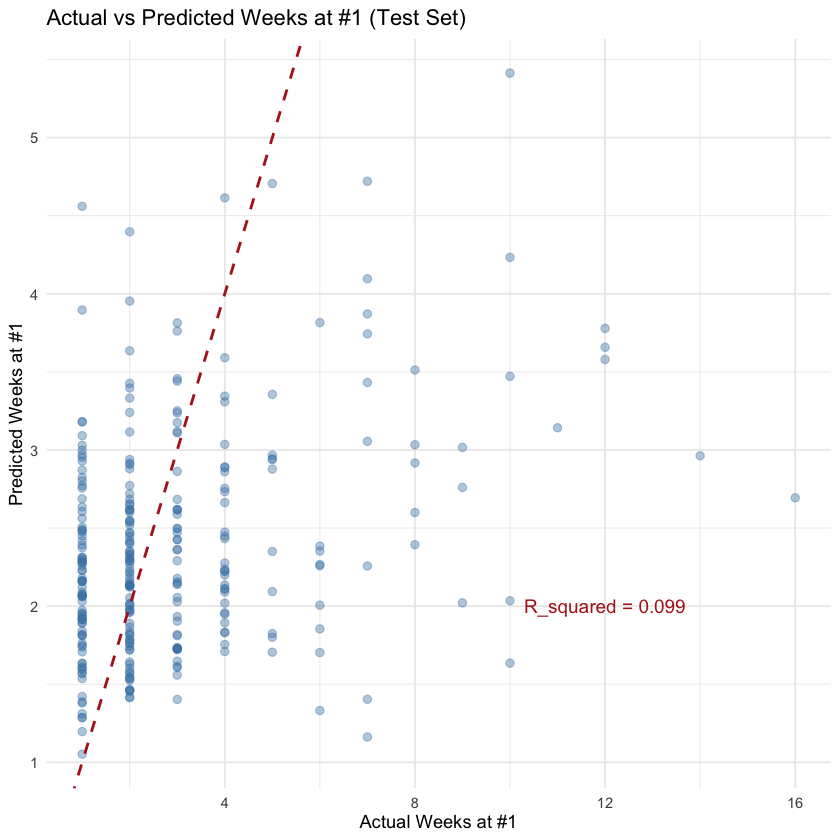

In [82]:
rsq_label <- paste0(
  "R_squared = ",
  round(
    test_predictions |>
      metrics(truth = actual, estimate = predicted) |>
      filter(.metric == "rsq") |>
      pull(.estimate),
    3
  )
)

p_actual_vs_predicted <- test_predictions |>
  mutate(
    actual_weeks    = expm1(actual),
    predicted_weeks = expm1(predicted)
  ) |>
  ggplot(aes(x = actual_weeks, y = predicted_weeks)) +
  geom_point(alpha = 0.4, colour = "steelblue", size = 2) +
  geom_abline(
    slope     = 1,
    intercept = 0,
    linetype  = "dashed",
    colour    = "firebrick",
    linewidth = 0.8
  ) +
  annotate(
    "text",
    x      = 12,
    y      = 2,
    label  = rsq_label, 
    colour = "firebrick",
    size   = 4
  ) +
  labs(
    title    = "Actual vs Predicted Weeks at #1 (Test Set)",
    x        = "Actual Weeks at #1",
    y        = "Predicted Weeks at #1"
  ) +
  theme_minimal()

p_actual_vs_predicted

*Figure 4. Actual vs predicted weeks at number one on the test set (original scale).*

Top 15 predictors by standardized coefficient magnitude, with color indicating positive or negative effect on the response.


In [ ]:
coef_data <- extract_top_coefficients(extract_fit_engine(final_fit), n = 15)

p_coefficients <- ggplot(
  coef_data,
  aes(x = reorder(term, abs(estimate)), y = estimate, fill = direction)
) +
  geom_col(show.legend = TRUE) +
  coord_flip() +
  scale_fill_manual(
    values = c("Positive" = "steelblue", "Negative" = "firebrick"),
    name   = "Effect on\nlog(weeks + 1)"
  ) +
  labs(
    title    = "Top 15 Predictors by Coefficient Magnitude",
    x        = NULL,
    y        = "Standardised Coefficient"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

p_coefficients
coef_data

*Figure 5. Top 15 predictors by standardised coefficient magnitude.*

#### Result Interpretation

The linear regression model shows weak predictive performance for explaining the number of weeks a song remains at number one on the Billboard chart. Cross-validation produced an average $R^2 = 0.063$ with `RMSE = 0.505` and `MAE = 0.415`, while evaluation on the test set yielded similar results ($R^2 = 0.052$, `RMSE = 0.502`, `MAE = 0.395`). The similarity between cross-validation and test metrics suggests that the model generalizes consistently and does not suffer from substantial overfitting. However, the low $R^2$ values indicate that the predictors explain only a small portion of the variation in chart longevity.

The predicted versus actual plot further illustrates this limitation. Predictions tend to cluster around relatively low values regardless of the true outcome, indicating that the model struggles to capture songs that remain at number one for longer periods. Instead the prediction gravitate toward the average, suggesting the model is unable to identify strong signals that distinguish highly successful songs from others.

Among the predictors, energy has the strongest standardized effect ($\beta = -0.119, p < 0.001$), indicating that lower-energy songs are associated with slightly longer duration at number one. Loudness ($\beta = 0.096, p < 0001$) and overall rating ($\beta = 0.061, p = 0.003$) show positive and statistically significant relationships with chart longevity, suggesting that songs with stronger perceived production intensity and higher ratings may remain popular for longer periods. Some structural features such as vocal introduction and handclasps/snaps also show modest positive associations, while elements like horns/winds and guitar-based instrumentation show small negative effects.

However, most predictors are not are not statistically significant, indicating that these characteristics contribute little predictive signal once audio features are accounted for. Overall, these findings suggest that musical attributes alone are insufficient to explain how long a song remains at number one.

### Discussion

The objective of our analysis was to use a linear regression model to predict the number of weeks a song would remain at the #1 spot of the Billboard Hot 100 song rankings (`weeks_at_number_one`) given open source data. Unnecessary features and features risking data-leakage into the predictive model were removed, and the skewed numerical features were transformed. One Hot Encoding was applied on categorical features, including genre and musical key; to predict on the data. Following this preprocessing, the linear regression model was trained the predictions were compared to the ground truth of weeks at the #1 spot. We found that in spite of its limited predictive power, that the model generalizes well onto unseen data due to the small difference between training and testing error, and that the top 3 statistically significant features involved in prediction were Energy, Loudness, and overall rating. From the coefficient values, we can conclude that weeks a song remains at the number one position is most associated with lower energy, higher loudness, and higher overall popularity.

Previous literature has also investigated song popularity with various models including KNN, linear regression, Random forest (and other tree-based models), and neural networks. Although these models have varying levels of predictive performance, song popularity is documented as a challenge to predict due to the nuanced level of the problem. Factors including individual preferences, globalization of music through various streaming platforms, and global events contribute to the challenge of measuring and influencing song popularity. [@ts2023] Further, global music trends and top performing artists have shifted since the introduction of streaming platforms, and song lengths have decreased to adjust to preferences over time. [@kim2021; @ts2023] Since our analysis spans multiple decades, world events, and to the adjustment of streaming platforms, these external factors could be influencing our $R^2$ value and error metrics. This means that songs with popular characteristic features leading to a high number of weeks at the top position from the 1950’s or 60’s, may not generalize well to features from popular songs in the 21st century. Therefore, the low preodicitive power of our model was expected.

A specific example of classifier implementation was conducted by Kim in 2021. This study, similar to the present study, investigated the impact of various features contributing to song popularity from 2010-2019 using Spotify data, and analyzed the performance through the RMSE of logistic regression, KNN, and Random Forest models. The lowest RMSE score was associated with the logistic regression model, followed by KNN and Random forest. [@kim2021]

Overall, this regression model provides good predictions given the data, historical trends in music forecasting, and questions being investigated; in spite of its weak predictive patterns. It adds to previous literature, by implementing different features and conducting a longitudinal study. The impact of our results can be used to determine how trends in music have changed overtime. Based on our findings, improvements/future research quests can be made through training separate models for the data into the 20th vs the 21st century, or by decade, to improve performance; while retaining longitudinal nature.

### References